In [1]:
import pandas as pd

df = pd.read_csv('experiments_results.csv')
df['experiment_group'] = df['experiment_name'].str.extract(r'(H\d)')

print('=== H1 scaling results ===')
print(df[df['experiment_name'].str.contains('H1')][['experiment_name','num_params','model_size_mb','avg_rtf','avg_generator_rtf','pesq','stoi','mel_l1']])

print('\n=== H2 quantization ===')
print(df[df['experiment_name'].str.contains('H2')][['experiment_name','num_params','model_size_mb','avg_rtf','avg_generator_rtf','pesq','stoi','mel_l1']])

print('\n=== H3 pruning by ratio ===')
for ratio in [0.3, 0.5, 0.7]:
        mask = (df['experiment_name'].str.contains('H3')) & (df['experiment_name'].str.contains(f'pruned{int(ratio*100)}'))
        print(df[mask][['experiment_name','num_params','model_size_mb','avg_rtf','avg_generator_rtf','pesq','stoi','mel_l1']])

print('\n=== H4 pruning + quantization ===')
for ratio in [0.3, 0.5, 0.7]:
        mask = (df['experiment_name'].str.contains('H4')) & (df['experiment_name'].str.contains(f'pruned{int(ratio*100)}'))
        print(df[mask][['experiment_name','num_params','model_size_mb','avg_rtf','avg_generator_rtf','pesq','stoi','mel_l1']])


=== H1 scaling results ===
     experiment_name  num_params  model_size_mb  avg_rtf  avg_generator_rtf  \
4   H1_256C_baseline     3560706         13.660   0.2587             0.2580   
5   H1_128C_baseline      928514          3.617   0.2455             0.2449   
10  H1_512C_baseline    13936130         53.239   0.3090             0.3084   

        pesq      stoi    mel_l1  
4   2.815303  0.951450  0.254826  
5   2.422547  0.933293  0.306314  
10  3.044655  0.961510  0.206027  

=== H2 quantization ===
                           experiment_name  num_params  model_size_mb  \
0                    H2_128C_quantized_all      926393          1.137   
1              H2_128C_quantized_no_output      926393          1.137   
2                    H2_256C_quantized_all     3556057          3.688   
3              H2_256C_quantized_no_output     3556057          3.687   
6    H2_128C_quantized_resblocks_range_2_9      926177          2.451   
7    H2_128C_quantized_resblocks_range_2_9      92617

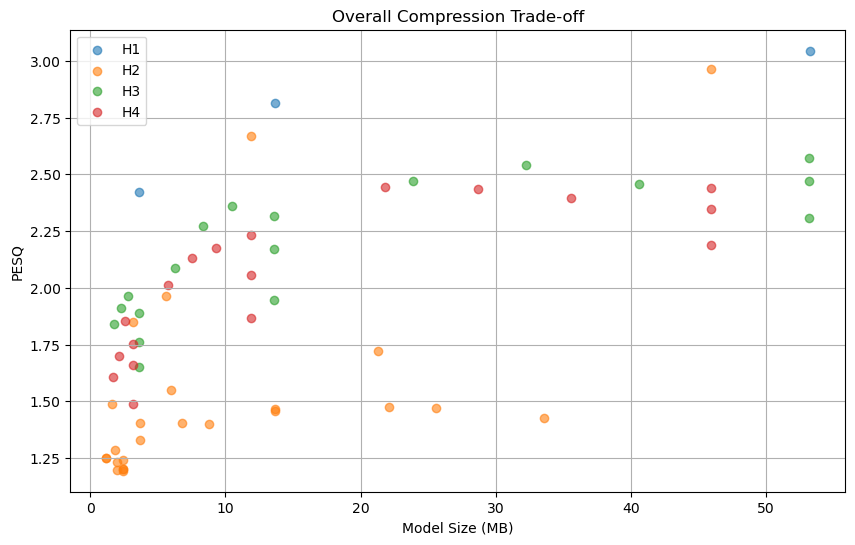

In [2]:
import matplotlib.pyplot as plt

df['group'] = df['experiment_name'].str.extract(r'(H\d)')

plt.figure(figsize=(10,6))

for g in ['H1','H2','H3','H4']:
    sub = df[df['experiment_name'].str.contains(g)]
    plt.scatter(sub['model_size_mb'], sub['pesq'], label=g, alpha=0.6)

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("Overall Compression Trade-off")
plt.legend()
plt.grid()
plt.show()

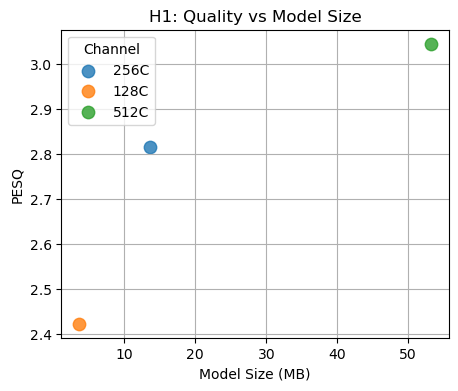

In [3]:
import matplotlib.pyplot as plt

h1 = df[df['experiment_name'].str.contains('H1')].copy()
h1['channel'] = h1['experiment_name'].str.extract(r'(\d+C)')


plt.figure(figsize=(5,4))

for ch in h1['channel'].unique():
    sub = h1[h1['channel'] == ch]

    plt.scatter(
        sub['model_size_mb'],
        sub['pesq'],
        label=ch,
        s=80,
        alpha=0.8
    )

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("H1: Quality vs Model Size")
plt.grid(True)
plt.legend(title="Channel")
plt.show()

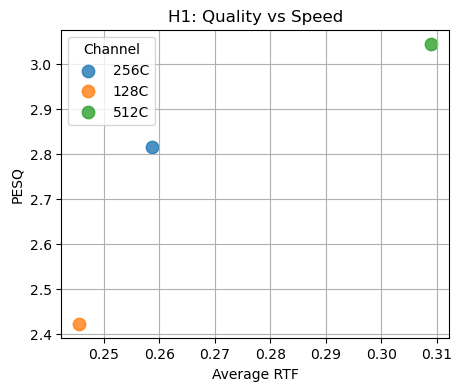

In [4]:
import matplotlib.pyplot as plt

h1 = df[df['experiment_name'].str.contains('H1')].copy()
h1['channel'] = h1['experiment_name'].str.extract(r'(\d+C)')


plt.figure(figsize=(5,4))

for ch in h1['channel'].unique():
    sub = h1[h1['channel'] == ch]

    plt.scatter(
        sub['avg_rtf'],
        sub['pesq'],
        label=ch,
        s=80,
        alpha=0.8
    )

plt.xlabel("Average RTF")
plt.ylabel("PESQ")
plt.title("H1: Quality vs Speed")
plt.grid(True)
plt.legend(title="Channel")
plt.show()

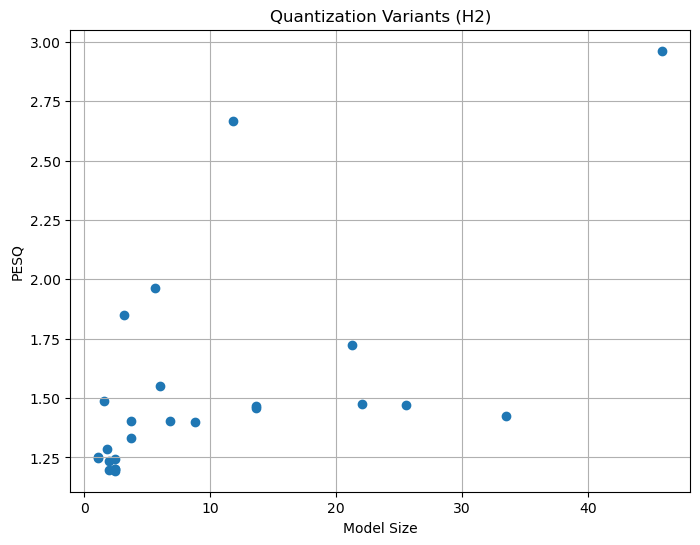

In [5]:
h2 = df[df['experiment_name'].str.contains('H2')].copy()
plt.figure(figsize=(8,6))
plt.scatter(h2['model_size_mb'], h2['pesq'])

plt.xlabel("Model Size")
plt.ylabel("PESQ")
plt.title("Quantization Variants (H2)")
plt.grid()
plt.show()

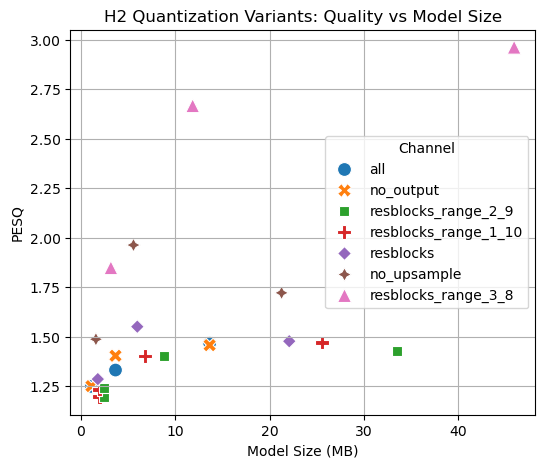

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

h2 = df[df['experiment_name'].str.contains('H2')].copy()
h2['variant'] = h2['experiment_name'].str.extract(r'(all|no_output|no_upsample|resblocks_range_\d+_\d+|resblocks)')

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=h2,
    x='model_size_mb',
    y='pesq',
    hue='variant',
    style='variant',
    s=100
)


plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("H2 Quantization Variants: Quality vs Model Size")
plt.grid(True)
plt.legend(title="Channel")
plt.show()

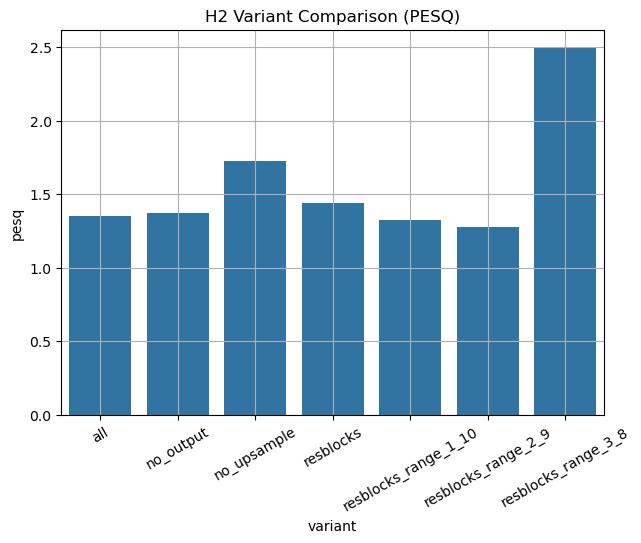

In [7]:
plt.figure(figsize=(7,5))

summary = h2.groupby('variant')[['pesq','stoi','avg_rtf']].mean().reset_index()

sns.barplot(data=summary, x='variant', y='pesq')

plt.title("H2 Variant Comparison (PESQ)")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

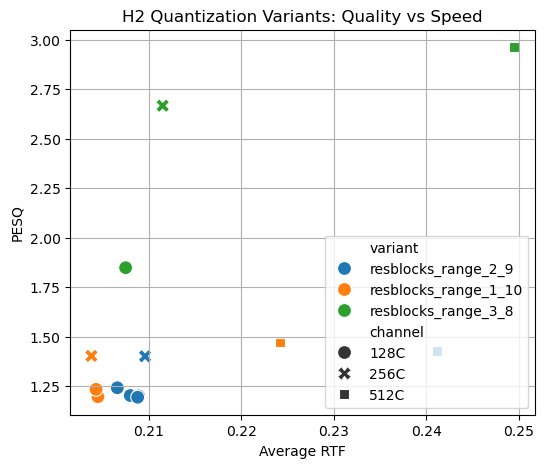

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

h2 = df[df['experiment_name'].str.contains('H2')].copy()
h2['variant'] = h2['experiment_name'].str.extract(r'(resblocks_range_\d+_\d+)')
h2['channel'] = h2['experiment_name'].str.extract(r'(\d+C)')

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=h2,
    x='avg_rtf',
    y='pesq',
    hue='variant',
    style='channel',
    s=100
)

plt.xlabel("Average RTF")
plt.ylabel("PESQ")
plt.title("H2 Quantization Variants: Quality vs Speed")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

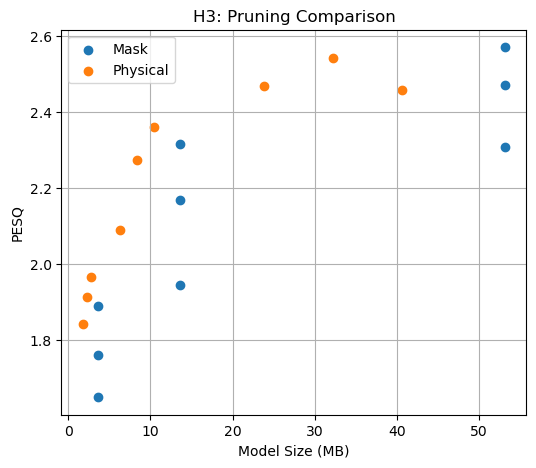

In [9]:
h3 = df[df['experiment_name'].str.contains('H3')]

plt.figure(figsize=(6,5))

for t in ['Mask','Physical']:
    sub = h3[h3['experiment_name'].str.contains(t)]
    plt.scatter(sub['model_size_mb'], sub['pesq'], label=t)

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("H3: Pruning Comparison")
plt.legend()
plt.grid()
plt.show()

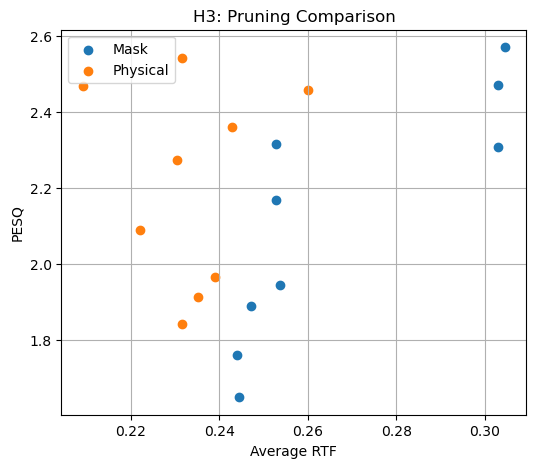

In [10]:
h3 = df[df['experiment_name'].str.contains('H3')]
plt.figure(figsize=(6,5))
for t in ['Mask','Physical']:
    sub = h3[h3['experiment_name'].str.contains(t)]
    plt.scatter(sub['avg_rtf'], sub['pesq'], label=t)

plt.xlabel("Average RTF")
plt.ylabel("PESQ")
plt.title("H3: Pruning Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

h4 = df[df['experiment_name'].str.contains('H4')].copy()

h4['prune'] = h4['experiment_name'].str.extract(r'pruned(\d+)').astype(float)

h4['channel'] = h4['experiment_name'].str.extract(r'(\d+C)')

color_map = {
    30: '#1f77b4',  # blue
    50: '#ff7f0e',  # orange
    70: '#2ca02c'   # green
}

# marker：channel
marker_map = {
    '512C': 'o',
    '256C': 's',
    '128C': '^'
}

plt.figure(figsize=(6,5))

for p in sorted(h4['prune'].unique()):
    for ch in h4['channel'].unique():

        sub = h4[(h4['prune'] == p) & (h4['channel'] == ch)]

        if len(sub) == 0:
            continue

        plt.scatter(
            sub['model_size_mb'],
            sub['pesq'],
            color=color_map.get(p, 'gray'),
            marker=marker_map.get(ch, 'o'),
            s=90,
            alpha=0.75,
            label=f"{p}% - {ch}"
        )

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("H4: Hybrid Compression Trade-off")
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=8)
plt.legend(loc="lower right")
plt.show()

KeyError: 'Mask'

<Figure size 600x500 with 0 Axes>

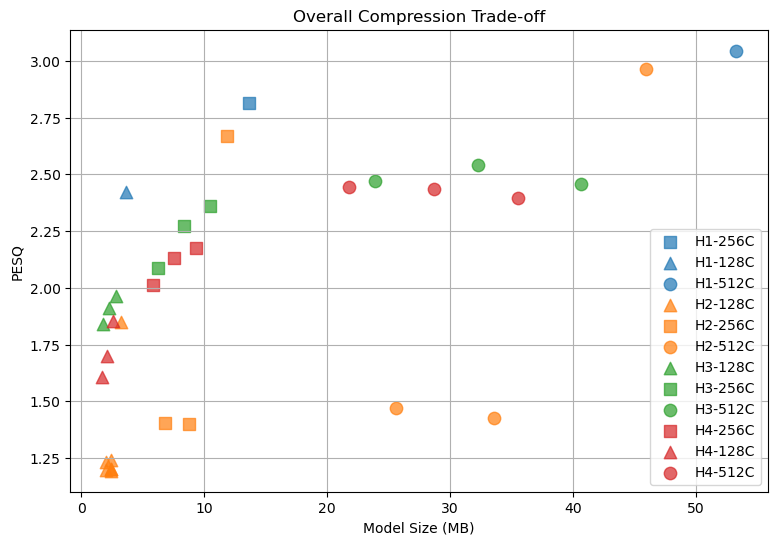

In [13]:
import matplotlib.pyplot as plt

df['experiment_group'] = df['experiment_name'].str.extract(r'(H\d)')
df['channel'] = df['experiment_name'].str.extract(r'(\d+C)')

marker_map = {
    '512C': 'o',
    '256C': 's',
    '128C': '^'
}

color_map = {
    'H1': '#1f77b4',  # blue
    'H2': '#ff7f0e',  # orange
    'H3': '#2ca02c',  # green
    'H4': '#d62728'   # red
}

plt.figure(figsize=(9,6))

for g in ['H1', 'H2', 'H3', 'H4']:

    if g == 'H1':
        sub = df[df['experiment_group'] == 'H1']

    elif g == 'H2':
        sub = df[
            (df['experiment_group'] == 'H2') &
            (df['experiment_name'].str.contains('resblocks_range'))
        ]

    elif g == 'H3':
        sub = df[
            (df['experiment_group'] == 'H3') &
            (df['experiment_name'].str.contains('Physical_pruning'))
        ]

    elif g == 'H4':
        sub = df[
            (df['experiment_group'] == 'H4') &
            (df['experiment_name'].str.contains('Physical_pruning'))
        ]

    for ch in sub['channel'].unique():
        s = sub[sub['channel'] == ch]

        plt.scatter(
            s['model_size_mb'],
            s['pesq'],
            label=f"{g}-{ch}",
            color=color_map[g],
            marker=marker_map.get(ch, 'o'),
            alpha=0.7,
            s=80
        )

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("Overall Compression Trade-off")
plt.grid(True)
plt.legend()
plt.show()

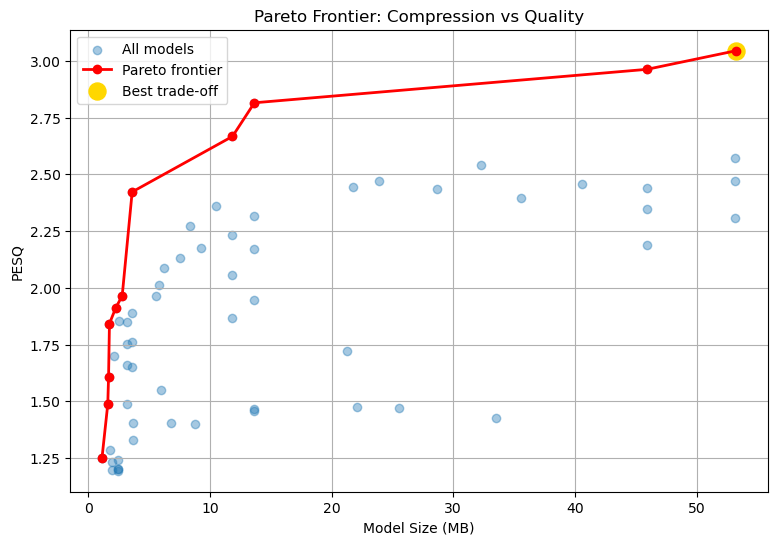

In [14]:
df_sorted = df.sort_values(['model_size_mb', 'pesq'], ascending=[True, False])

pareto = []
best_pesq = -1

for _, row in df_sorted.iterrows():
    if row['pesq'] > best_pesq:
        pareto.append(row)
        best_pesq = row['pesq']

pareto_df = pd.DataFrame(pareto)

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# 所有点
plt.scatter(df['model_size_mb'], df['pesq'], alpha=0.4, label='All models')

# Pareto frontier
plt.plot(
    pareto_df['model_size_mb'],
    pareto_df['pesq'],
    marker='o',
    color='red',
    linewidth=2,
    label='Pareto frontier'
)

# 标注最优点
best = pareto_df.iloc[-1]
plt.scatter(
    best['model_size_mb'],
    best['pesq'],
    color='gold',
    s=150,
    label='Best trade-off'
)

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("Pareto Frontier: Compression vs Quality")
plt.legend()
plt.grid()
plt.show()


                                      experiment_name  model_size_mb      pesq
1                         H2_128C_quantized_no_output          1.137  1.250069
22                      H2_128C_quantized_no_upsample          1.613  1.487182
61  H4_128C_pruned70_int8_Physical_pruning_resbloc...          1.678  1.608257
44                  H3_128C_pruned70_Physical_pruning          1.750  1.842384
37                  H3_128C_pruned50_Physical_pruning          2.274  1.912461
31                  H3_128C_pruned30_Physical_pruning          2.797  1.964553
5                                    H1_128C_baseline          3.617  2.422547
27              H2_256C_quantized_resblocks_range_3_8         11.861  2.667206
4                                    H1_256C_baseline         13.660  2.815303
30              H2_512C_quantized_resblocks_range_3_8         45.910  2.962607
10                                   H1_512C_baseline         53.239  3.044655


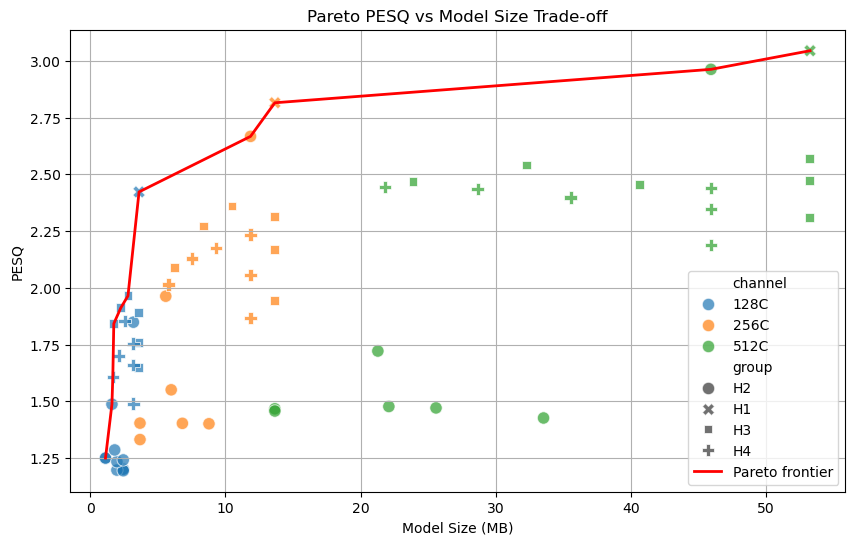

In [17]:
df['group'] = df['experiment_name'].str.extract(r'(H\d)')
df['channel'] = df['experiment_name'].str.extract(r'(\d+C)')
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='model_size_mb',
    y='pesq',
    hue='channel',
    style='group',
    alpha=0.7,
    s=80
)

# ---- Pareto frontier ----
df_sorted = df.sort_values(['model_size_mb', 'pesq'], ascending=[True, False])

pareto = []
best = -1
for _, r in df_sorted.iterrows():
    if r['pesq'] > best:
        pareto.append(r)
        best = r['pesq']

pareto = pd.DataFrame(pareto)
print(pareto[['experiment_name', 'model_size_mb', 'pesq']])

plt.plot(
    pareto['model_size_mb'],
    pareto['pesq'],
    color='red',
    linewidth=2,
    label='Pareto frontier'
)

plt.xlabel("Model Size (MB)")
plt.ylabel("PESQ")
plt.title("Pareto PESQ vs Model Size Trade-off")
plt.grid(True)
plt.legend()
plt.show()

                                      experiment_name  avg_generator_rtf  \
0                               H2_128C_quantized_all             0.0268   
1                         H2_128C_quantized_no_output             0.0275   
2                               H2_256C_quantized_all             0.0552   
3                         H2_256C_quantized_no_output             0.0571   
15                              H2_512C_quantized_all             0.1423   
63  H4_512C_pruned70_int8_Physical_pruning_resbloc...             0.1785   
47                  H3_512C_pruned70_Physical_pruning             0.2085   
27              H2_256C_quantized_resblocks_range_3_8             0.2109   
30              H2_512C_quantized_resblocks_range_3_8             0.2490   
10                                   H1_512C_baseline             0.3084   

        pesq  
0   1.248798  
1   1.250069  
2   1.331503  
3   1.403835  
15  1.467090  
63  2.443227  
47  2.469339  
27  2.667206  
30  2.962607  
10  3.044655 

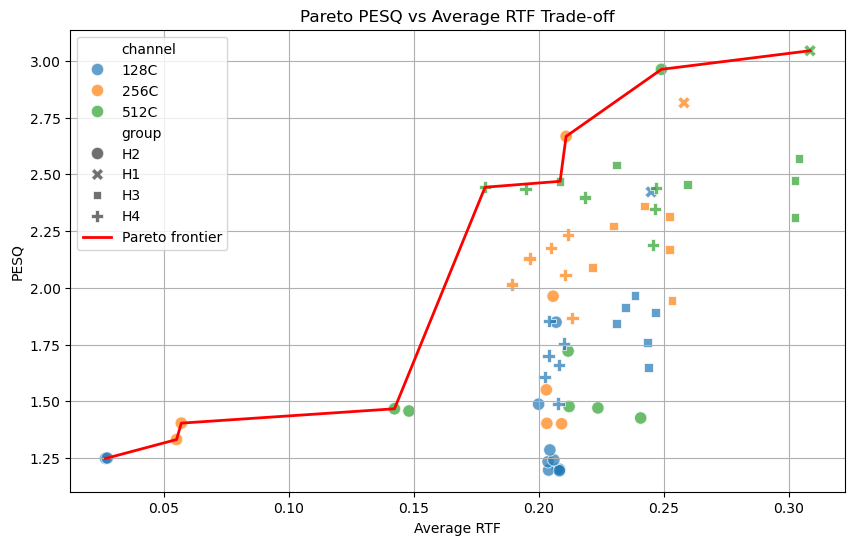

In [18]:
df['group'] = df['experiment_name'].str.extract(r'(H\d)')
df['channel'] = df['experiment_name'].str.extract(r'(\d+C)')
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='avg_generator_rtf',
    y='pesq',
    hue='channel',
    style='group',
    alpha=0.7,
    s=80
)

# ---- Pareto frontier ----
df_sorted = df.sort_values(['avg_generator_rtf', 'pesq'], ascending=[True, False])

pareto = []
best = -1
for _, r in df_sorted.iterrows():
    if r['pesq'] > best:
        pareto.append(r)
        best = r['pesq']

pareto = pd.DataFrame(pareto)
print(pareto[['experiment_name', 'avg_generator_rtf', 'pesq']])

plt.plot(
    pareto['avg_generator_rtf'],
    pareto['pesq'],
    color='red',
    linewidth=2,
    label='Pareto frontier'
)

plt.xlabel("Average RTF")
plt.ylabel("PESQ")
plt.title("Pareto PESQ vs Average RTF Trade-off")
plt.grid(True)
plt.legend()
plt.show()